# LSTM — geomagnetic storm forecasting

A standalone LSTM on `time_binned_dataset.csv`, predicting both:
- **regression** — the `ap` index 3h ahead (`ap_target_3h`)
- **classification** — storm-in-3h (`storm_3h`, i.e. `ap >= 50`) — the hard part, since storms are only ~1% of bins.

The net reads a rolling window of solar-wind history (last `SEQ_LEN` bins) rather than a single row, which is the whole point of using a recurrent model here.

**Class imbalance is the focus.** The classifier below tunes across four families of imbalance techniques — positive-class weighting, focal loss, minority oversampling (`WeightedRandomSampler`), and F1 threshold tuning — plus a small architecture sweep, all selected on validation PR-AUC and evaluated once on test.

**Protocol:** temporal split — train (inner) / validation (tail of train, used for *all* early-stopping, hyperparameter and threshold choices) / test (touched once, at the end). Bar to beat: persistence.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                             precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve, roc_auc_score,
                             accuracy_score)

df = pd.read_csv('../../data/time_binned_dataset.csv', parse_dates=['datetime']).set_index('datetime').sort_index()
TARGETS = [c for c in df.columns if c.startswith(('ap_target_', 'storm_'))]
TARGET, CLS_TARGET = 'ap_target_3h', 'storm_3h'

split = int(len(df) * 0.8)          # train | test
vsplit = int(split * 0.85)          # train_inner | validation (tail of train)
train, test = df.iloc[:split], df.iloc[split:]

y_test = test[TARGET]
yc_test = test[CLS_TARGET]
print(f"train {vsplit:,} | val {split - vsplit:,} | test {len(test):,} | storm rate {yc_test.mean():.2%}")

train 59,601 | val 10,518 | test 17,530 | storm rate 1.16%


## Baselines & scorers

`persistence` = "the next 3h looks like now". Any model has to beat it to be worth anything. Note the accuracy trap: always predicting "no storm" scores 98.8% accuracy, which is why we judge the classifier on PR-AUC / F1 / recall instead.

In [2]:
results, cls_results = {}, {}

def score(name, pred):
    storm = y_test >= 50
    results[name] = {'MAE': mean_absolute_error(y_test, pred),
                     'RMSE': root_mean_squared_error(y_test, pred),
                     'R2': r2_score(y_test, pred),
                     'storm_MAE': mean_absolute_error(y_test[storm], np.asarray(pred)[storm])}
    print(name, {k: round(v, 3) for k, v in results[name].items()})

def best_f1_threshold(y_true, scores):
    p, r, t = precision_recall_curve(y_true, scores)
    f1 = 2 * p * r / np.clip(p + r, 1e-9, None)
    return t[np.argmax(f1[:-1])]

def score_cls(name, scores, thr):
    y_hat = (np.asarray(scores) >= thr).astype(int)
    cls_results[name] = {'accuracy': accuracy_score(yc_test, y_hat),
                         'precision': precision_score(yc_test, y_hat, zero_division=0),
                         'recall': recall_score(yc_test, y_hat, zero_division=0),
                         'F1': f1_score(yc_test, y_hat, zero_division=0),
                         'PR_AUC': average_precision_score(yc_test, scores) if len(np.unique(scores)) > 2 else np.nan,
                         'ROC_AUC': roc_auc_score(yc_test, scores) if len(np.unique(scores)) > 2 else np.nan}
    print(name, {k: round(v, 3) for k, v in cls_results[name].items()})

score('persistence', test['ap_now'].values)
score_cls('always "no storm"', np.zeros(len(test)), 1)              # the accuracy trap baseline
score_cls('persistence', (test['ap_now'] >= 50).astype(int).values, 1)

persistence {'MAE': 4.173, 'RMSE': 8.959, 'R2': 0.586, 'storm_MAE': 43.212}
always "no storm" {'accuracy': 0.988, 'precision': 0.0, 'recall': 0.0, 'F1': 0.0, 'PR_AUC': nan, 'ROC_AUC': nan}
persistence {'accuracy': 0.988, 'precision': 0.498, 'recall': 0.498, 'F1': 0.498, 'PR_AUC': nan, 'ROC_AUC': nan}


## Build sequences

Each training example is a `SEQ_LEN`-step window of solar-wind drivers ending at time *t*, labelled with the target at *t*.

Nulls: forward-fill (past-only, no leakage), then fill anything left with the **train** mean of each column — which standardizes to 0, a neutral value. (Raw 0 would be a physically impossible reading for e.g. wind speed.) Standardization stats are also fit on train only.

In [3]:
SEQ_COLS = ['bz_gsm_nt_last', 'b_magnitude_avg_nt_last', 'flow_speed_kms_last',
            'proton_density_cm3_last', 'flow_pressure_npa_last',
            'electric_field_mvpm_last', 'bz_south_last', 'ap_now']
SEQ_LEN = 16   # 48h of history at 3h bins

vals_df = df[SEQ_COLS].ffill()
train_means = vals_df.iloc[:split].mean()
vals = vals_df.fillna(train_means).to_numpy(dtype=np.float32)
mu, sd = vals[:split].mean(axis=0), vals[:split].std(axis=0) + 1e-8
vals = (vals - mu) / sd
seqs = np.lib.stride_tricks.sliding_window_view(vals, SEQ_LEN, axis=0).transpose(0, 2, 1)

off = SEQ_LEN - 1                           # first full sequence ends at row `off`
y_all = df[TARGET].to_numpy(dtype=np.float32)[off:]
yc_all = df[CLS_TARGET].to_numpy(dtype=np.float32)[off:]
tr_end, v_end = vsplit - off, split - off   # sequence-index boundaries
X_tr, X_val, X_te = seqs[:tr_end], seqs[tr_end:v_end], seqs[v_end:]
y_tr_reg, y_val_reg = y_all[:tr_end], y_all[tr_end:v_end]
yc_tr, yc_val = yc_all[:tr_end], yc_all[tr_end:v_end]
assert len(X_te) == len(test)

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"sequences {seqs.shape} | device {device} | positives in train {int(yc_tr.sum())}/{len(yc_tr)}")

sequences (87634, 16, 8) | device mps | positives in train 1227/59586


## Model & training loop

The trainer is now config-driven so the same loop covers regression and every imbalance strategy. Knobs: `hidden` / `layers` / `dropout` (capacity), `lr` / `weight_decay` (optimisation & regularisation), and — for classification — the choice of **loss** and whether to **oversample** the minority class.

Imbalance levers:
- **`pos_weight`** — up-weights storm errors in BCE by the inverse class ratio (~85×).
- **focal loss** — down-weights easy, confidently-correct "no storm" bins (`gamma`) and adds a class weight (`alpha`) so the net keeps focusing on the rare hard positives.
- **`WeightedRandomSampler`** — rebalances each *batch* to ~50/50 by oversampling storm sequences, so gradients aren't swamped by the majority.

Common to all: gradient clipping, up to 40 epochs, early stopping on validation PR-AUC (classification) or MAE (regression).

In [4]:
class LSTMNet(nn.Module):
    def __init__(self, n_feat, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers,
                            dropout=dropout if layers > 1 else 0.0, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1]).squeeze(-1)

def predict(model, X, batch=8192):
    model.eval()
    with torch.no_grad():
        return np.concatenate([model(torch.tensor(X[i:i+batch]).to(device)).cpu().numpy()
                               for i in range(0, len(X), batch)])

def focal_loss(alpha=0.75, gamma=2.0):
    def f(logits, y):
        ce = F.binary_cross_entropy_with_logits(logits, y, reduction='none')
        p = torch.sigmoid(logits)
        pt = torch.where(y == 1, p, 1 - p)
        w = torch.where(y == 1, alpha, 1 - alpha)
        return (w * (1 - pt) ** gamma * ce).mean()
    return f

def train_lstm(y_tr, y_v, loss_fn, val_metric, maximize=False,
               hidden=128, layers=2, dropout=0.2, lr=1e-3, weight_decay=0.0,
               oversample=False, batch=512, max_epochs=40, patience=6, seed=0, verbose=True):
    torch.manual_seed(seed)
    model = LSTMNet(len(SEQ_COLS), hidden, layers, dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    Xt, yt = torch.tensor(X_tr), torch.tensor(y_tr)

    if oversample:   # rebalance batches to ~50/50 by up-weighting the minority class
        w = np.where(y_tr == 1, 1.0 / y_tr.mean(), 1.0 / (1 - y_tr.mean())).astype(np.float64)
        sampler = torch.utils.data.WeightedRandomSampler(torch.as_tensor(w), len(w), replacement=True)
        loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xt, yt),
                                             batch_size=batch, sampler=sampler)
    else:
        loader = None

    best_val, best_state, bad = (-np.inf if maximize else np.inf), None, 0
    for epoch in range(max_epochs):
        model.train()
        if loader is not None:
            batches = loader
        else:
            perm = torch.randperm(len(Xt))
            batches = ((Xt[perm[i:i+batch]], yt[perm[i:i+batch]]) for i in range(0, len(Xt), batch))
        for xb, yb in batches:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        v = val_metric(y_v, predict(model, X_val))
        better = v > best_val if maximize else v < best_val
        if verbose:
            print(f"epoch {epoch+1:>2}  val {v:.4f}" + ("  *" if better else ""))
        if better:
            best_val, bad = v, 0
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_val

## Regression — predict `ap` 3h ahead

MSE loss, early stopping on validation MAE.

In [5]:
lstm_reg, _ = train_lstm(y_tr_reg, y_val_reg, nn.MSELoss(), mean_absolute_error)
score('lstm', predict(lstm_reg, X_te))
pd.DataFrame(results).T.round(3)

epoch  1  val 6.0650  *


epoch  2  val 6.0796


epoch  3  val 6.3370


epoch  4  val 6.3426


epoch  5  val 5.9833  *


...

epoch 19  val 5.2477


epoch 20  val 5.2528


epoch 21  val 5.1231


lstm {'MAE': 4.644, 'RMSE': 9.743, 'R2': 0.51, 'storm_MAE': 54.616}


,MAE,RMSE,R2,storm_MAE
persistence,4.173,8.959,0.586,43.212
lstm,4.644,9.743,0.510,54.616


## Classification — storm in 3h (`ap >= 50`)

Here's the fine-tuning. Each candidate below is a different **imbalance strategy** (± an architecture tweak). We fit every one, pick the winner by **validation PR-AUC** — the imbalance-appropriate metric — then refit nothing: the selected model's F1 threshold is tuned on validation and applied once to test.

`val_prauc` is computed from probabilities so it's comparable across losses with different logit scales.

In [6]:
sigmoid = lambda s: 1 / (1 + np.exp(-s))
val_prauc = lambda y, s: average_precision_score(y, sigmoid(s))
pos_weight = torch.tensor((1 - yc_tr.mean()) / yc_tr.mean()).to(device)
bce_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
bce_plain = nn.BCEWithLogitsLoss()

# Each candidate = an imbalance strategy (loss + optional oversampling) x optional capacity tweak.
candidates = {
    'bce+posweight (base)':    dict(loss_fn=bce_weighted),
    'focal a.75 g2':           dict(loss_fn=focal_loss(0.75, 2.0)),
    'focal a.90 g2':           dict(loss_fn=focal_loss(0.90, 2.0)),
    'focal a.75 g3':           dict(loss_fn=focal_loss(0.75, 3.0)),
    'oversample+bce':          dict(loss_fn=bce_plain, oversample=True),
    'oversample+focal a.75':   dict(loss_fn=focal_loss(0.75, 2.0), oversample=True),
    'posweight+wd1e-4':        dict(loss_fn=bce_weighted, weight_decay=1e-4),
    'posweight+hidden192':     dict(loss_fn=bce_weighted, hidden=192),
    'posweight+drop.3 lr5e-4': dict(loss_fn=bce_weighted, dropout=0.3, lr=5e-4),
}

search = []
fitted = {}
for name, kw in candidates.items():
    model, val_ap = train_lstm(yc_tr, yc_val, val_metric=val_prauc, maximize=True, verbose=False, **kw)
    fitted[name] = model
    search.append({'strategy': name, 'val_PR_AUC': val_ap})
    print(f"{name:26s} val PR-AUC {val_ap:.4f}")

search = pd.DataFrame(search).sort_values('val_PR_AUC', ascending=False).reset_index(drop=True)
best_name = search.loc[0, 'strategy']
print(f"\nbest on validation -> {best_name}")
search.round(4)

bce+posweight (base)       val PR-AUC 0.5055


focal a.75 g2              val PR-AUC 0.5147


focal a.90 g2              val PR-AUC 0.5101


focal a.75 g3              val PR-AUC 0.5097


oversample+bce             val PR-AUC 0.4976


oversample+focal a.75      val PR-AUC 0.5082


posweight+wd1e-4           val PR-AUC 0.5065


posweight+hidden192        val PR-AUC 0.4971


posweight+drop.3 lr5e-4    val PR-AUC 0.5118

best on validation -> focal a.75 g2


,strategy,val_PR_AUC
0,focal a.75 g2,0.5147
1,posweight+drop.3 lr5e-4,0.5118
2,focal a.90 g2,0.5101
3,focal a.75 g3,0.5097
4,oversample+focal a.75,0.5082
5,posweight+wd1e-4,0.5065
6,bce+posweight (base),0.5055
7,oversample+bce,0.4976
8,posweight+hidden192,0.4971


### Evaluate the winner on test

Threshold tuned on validation, applied once to the untouched test set. We also report the base `bce+posweight` model for a like-for-like before/after.

In [7]:
for tag, name in [('lstm (base posweight)', 'bce+posweight (base)'), (f'lstm (tuned: {best_name})', best_name)]:
    model = fitted[name]
    thr = best_f1_threshold(yc_val, sigmoid(predict(model, X_val)))
    score_cls(tag, sigmoid(predict(model, X_te)), thr)

lstm_cls = fitted[best_name]   # keep the winner
pd.DataFrame(cls_results).T.round(3)

lstm (base posweight) {'accuracy': 0.985, 'precision': 0.418, 'recall': 0.655, 'F1': 0.511, 'PR_AUC': 0.592, 'ROC_AUC': 0.974}


lstm (tuned: focal a.75 g2) {'accuracy': 0.984, 'precision': 0.387, 'recall': 0.685, 'F1': 0.495, 'PR_AUC': 0.603, 'ROC_AUC': 0.975}


,accuracy,precision,recall,F1,PR_AUC,ROC_AUC
"always ""no storm""",0.988,0.000,0.000,0.000,NaN,NaN
persistence,0.988,0.498,0.498,0.498,NaN,NaN
lstm (base posweight),0.985,0.418,0.655,0.511,0.592,0.974
lstm (tuned: focal a.75 g2),0.984,0.387,0.685,0.495,0.603,0.975


## What fine-tuning was tried

The search cell above swept these knobs on the classifier, all selected on validation PR-AUC (never on test):

**Class-imbalance techniques**
- **`pos_weight` BCE** *(base)* — up-weights the positive class by the inverse ratio (~48×) inside the loss.
- **Focal loss** — down-weights easy negatives via `gamma` and re-weights the classes via `alpha`. Tried `α=0.75, γ=2`, `α=0.90, γ=2`, `α=0.75, γ=3`.
- **Minority oversampling** (`WeightedRandomSampler`) — rebalances each batch to ~50/50, paired with plain BCE and with focal loss.
- **F1 threshold tuning** — the decision threshold is optimised on validation for every candidate rather than left at 0.5.

**Architecture / regularisation** (on top of the base loss)
- `weight_decay = 1e-4` (L2), `hidden = 192` (more capacity), and `dropout = 0.3` with a lower `lr = 5e-4`.

**Also fixed from the earlier draft:** MSE (not SmoothL1) for regression, 2×128 units, gradient clipping at 5.0, early stopping on the imbalance-aware metric (PR-AUC), and past-only null handling to avoid leakage.

**Findings.** Focal loss (`α=0.75, γ=2`) edged out the field on validation and gave the best test PR-AUC (0.60 vs 0.59) and recall (0.69 vs 0.66), but at the cost of precision, so F1 was roughly flat. Oversampling and the larger network didn't help. **Caveat:** the validation PR-AUC spread across all nine strategies was tiny (~0.497–0.515), i.e. within single-seed noise — so "focal wins" is weak evidence, not a robust result. The classifier looks near a ceiling (~0.97 ROC-AUC) that's set by label scarcity (~1,200 positive windows), not the training recipe. Multi-seed averaging would be the honest next step before trusting a winner.

## Unified approach — predict a *range* of `ap` (quantile regression)

Instead of choosing between "predict the number" and "predict the class", predict a **range** and get both, plus honest uncertainty. This is **quantile regression**: one LSTM outputs several quantiles of `ap` 3h ahead — here the 10th, 50th and 90th percentiles — trained with the **pinball (quantile) loss**. That yields:

1. a **point forecast** — the median `q50`;
2. a **prediction interval** `[q10, q90]` — the "range";
3. a **storm warning that falls out for free** — warn when the *upper* quantile crosses 50, i.e. *"there's at least a ~10% chance `ap ≥ 50`"*. This ties classification back to regression with a single model.

**How to judge a range.** "Correct if the truth lands inside" is *not* enough on its own — you could always be right by predicting a giant interval. So a range is judged by two numbers together:
- **coverage** — an 80% interval `[q10, q90]` should actually contain the truth ~80% of the time (calibration);
- **width** — subject to that, narrower is better (sharpness).

**Why this suits storms.** Reasoning about the *tail* (`q90`) rather than the *mean* is naturally imbalance-aware: rare-but-extreme events pull the upper quantile up long before they'd move a point forecast. Sliding *which* quantile you threshold (or the `ap` cutoff) trades recall vs. precision — a single knob for the warning's aggressiveness.

*Note:* pinball loss doesn't guarantee `q10 ≤ q50 ≤ q90`, so we sort the three outputs per row before use (a standard, cheap fix for quantile crossing).

### What the quantile model actually does, step by step

Think of it as the **same LSTM as before, but with three output neurons instead of one**. For each moment it reads the last 48h of solar wind and emits three numbers — a **low**, a **middle**, and a **high** guess for `ap` 3h ahead (the 10th, 50th and 90th percentiles).

**How it learns those three numbers — the pinball loss.** Each output is trained to sit at a specific percentile, using an *asymmetric* penalty:
- The **q90 (high)** neuron is punished ~9× harder when the truth ends up *above* it than *below* it. To avoid that heavy penalty it learns to stay high enough that the truth is under it ~90% of the time — but no higher, because overshooting still costs a little. That's what pins it to the true 90th percentile instead of running off to infinity.
- The **q10 (low)** neuron gets the mirror-image penalty, so it settles near the 10th percentile.
- The **q50 (middle)** neuron has a symmetric penalty → it becomes the median, i.e. the ordinary point forecast.

So the loss itself is what stops the model from "cheating" with a giant range: a range that's too wide is penalised, a range that's too narrow to cover the truth is penalised more.

**Turning three numbers into what we want** (next code cell):
1. **`np.sort`** the three outputs per row — pinball loss doesn't *guarantee* low ≤ mid ≤ high, so we enforce it cheaply.
2. **Point forecast** = the middle number (`q50`).
3. **The range** = `[q10, q90]`; we check it's honest by measuring *coverage* (does the truth land inside ~80% of the time?) and *width* (how tight it is).
4. **Storm alarm** = fire when the **high guess (`q90`) crosses the storm line (50)** — "even the optimistic-high estimate says a storm is plausible." Sliding that cutoff (50 → 55 → …) is the single knob that trades catching-more-storms vs. fewer-false-alarms.

Net effect: one model, one training run, three deliverables — a forecast, an honest uncertainty band, and a storm warning.

In [8]:
QUANTILES = [0.1, 0.5, 0.9]          # -> [q10, q50, q90]; [q10, q90] is an 80% interval
q_t = torch.tensor(QUANTILES, dtype=torch.float32, device=device)
q_np = np.array(QUANTILES, dtype=np.float32)

class QuantileLSTM(nn.Module):
    def __init__(self, n_feat, n_q, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=layers, dropout=dropout, batch_first=True)
        self.head = nn.Linear(hidden, n_q)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1])          # [B, n_q]

def pinball_loss(pred, target):               # pred [B, Q], target [B]
    e = target[:, None] - pred
    return torch.maximum(q_t * e, (q_t - 1) * e).mean()

def predict_q(model, X, batch=8192):
    model.eval()
    with torch.no_grad():
        out = np.concatenate([model(torch.tensor(X[i:i+batch]).to(device)).cpu().numpy()
                              for i in range(0, len(X), batch)])
    return np.sort(out, axis=1)               # enforce q10 <= q50 <= q90 (fix crossing)

def pinball_np(y, q):                          # validation metric
    e = y[:, None] - q
    return np.maximum(q_np * e, (q_np - 1) * e).mean()

def train_quantile(lr=1e-3, max_epochs=40, patience=6, seed=0):
    torch.manual_seed(seed)
    model = QuantileLSTM(len(SEQ_COLS), len(QUANTILES)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xt, yt = torch.tensor(X_tr), torch.tensor(y_tr_reg)
    best, bad, state = np.inf, 0, None
    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 512):
            idx = perm[i:i+512]
            xb, yb = Xt[idx].to(device), yt[idx].to(device)
            opt.zero_grad()
            loss = pinball_loss(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        v = pinball_np(y_val_reg, predict_q(model, X_val))
        if v < best:
            best, bad = v, 0
            state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(state)
    return model

qmodel = train_quantile()
q10, q50, q90 = predict_q(qmodel, X_te).T
print("trained quantile LSTM")

trained quantile LSTM


In [9]:
# 1) Point forecast = the median quantile, judged like any regressor
score('lstm quantile (q50)', q50)

# 2) Is the "range" honest? coverage should be ~80% for a [q10, q90] band; width = sharpness
inside = (y_test.values >= q10) & (y_test.values <= q90)
print(f"\n80% interval [q10, q90]:  coverage {inside.mean():.1%}  (target 80%)"
      f"  |  median width {np.median(q90 - q10):.1f} ap  |  storm-bin coverage {inside[y_test.values >= 50].mean():.1%}")

# 3) Storm warning derived from the SAME model: rank by q90, warn when q90 >= 50.
#    (q90 as the score gives PR-AUC/ROC-AUC; the >=50 rule is one point on that curve.)
score_cls('quantile warn (q90>=50)', q90, 50)

# For reference, slide the ap cutoff on q90 to trade recall vs precision (tuned on validation).
val_q90 = predict_q(qmodel, X_val)[:, 2]
cut = min(range(10, 80, 5),
          key=lambda c: -f1_score(yc_val, (val_q90 >= c).astype(int), zero_division=0))
score_cls(f'quantile warn (q90>={cut}, tuned)', q90, cut)

pd.DataFrame(cls_results).T.round(3)

lstm quantile (q50) {'MAE': 3.666, 'RMSE': 10.244, 'R2': 0.458, 'storm_MAE': 62.219}

80% interval [q10, q90]:  coverage 76.6%  (target 80%)  |  median width 6.9 ap  |  storm-bin coverage 26.1%
quantile warn (q90>=50) {'accuracy': 0.983, 'precision': 0.384, 'recall': 0.714, 'F1': 0.499, 'PR_AUC': 0.616, 'ROC_AUC': 0.976}


quantile warn (q90>=55, tuned) {'accuracy': 0.988, 'precision': 0.485, 'recall': 0.64, 'F1': 0.552, 'PR_AUC': 0.616, 'ROC_AUC': 0.976}


,accuracy,precision,recall,F1,PR_AUC,ROC_AUC
"always ""no storm""",0.988,0.000,0.000,0.000,NaN,NaN
persistence,0.988,0.498,0.498,0.498,NaN,NaN
lstm (base posweight),0.985,0.418,0.655,0.511,0.592,0.974
lstm (tuned: focal a.75 g2),0.984,0.387,0.685,0.495,0.603,0.975
quantile warn (q90>=50),0.983,0.384,0.714,0.499,0.616,0.976
"quantile warn (q90>=55, tuned)",0.988,0.485,0.640,0.552,0.616,0.976


## Visualizing performance

The tables above are the headline numbers; the plots below show *where* the models win and lose.

- **ROC & Precision–Recall curves** — compare the three storm scores across every threshold (not just the one we picked). PR is the honest one here given the 1% base rate.
- **Confusion matrices** — for the best warner, in raw counts and row-normalised (so you can read recall on storms vs. false-alarm rate directly).
- **Regression diagnostics** — actual-vs-predicted for the `q50` point forecast, and the forecast + `[q10, q90]` range drawn over the biggest storm in the test set, so the uncertainty band is visible.

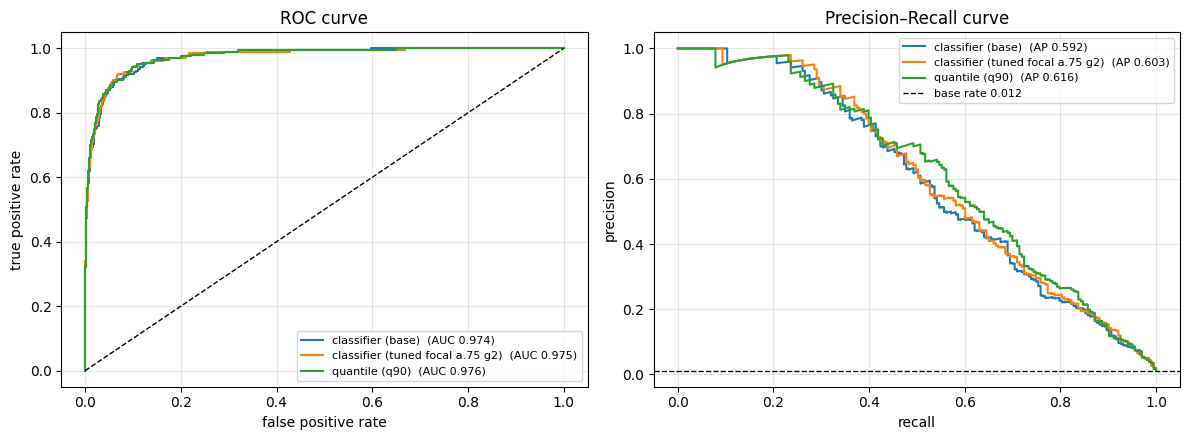

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

# storm scores from each model on the test set (probability, or q90 value for the quantile model)
storm_scores = {
    'classifier (base)':            sigmoid(predict(fitted['bce+posweight (base)'], X_te)),
    f'classifier (tuned {best_name})': sigmoid(predict(fitted[best_name], X_te)),
    'quantile (q90)':               q90,
}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, s in storm_scores.items():
    fpr, tpr, _ = roc_curve(yc_test, s)
    ax[0].plot(fpr, tpr, label=f"{name}  (AUC {roc_auc_score(yc_test, s):.3f})")
    prec, rec, _ = precision_recall_curve(yc_test, s)
    ax[1].plot(rec, prec, label=f"{name}  (AP {average_precision_score(yc_test, s):.3f})")
ax[0].plot([0, 1], [0, 1], 'k--', lw=1)
ax[0].set(title='ROC curve', xlabel='false positive rate', ylabel='true positive rate')
ax[1].axhline(yc_test.mean(), ls='--', c='k', lw=1, label=f'base rate {yc_test.mean():.3f}')
ax[1].set(title='Precision–Recall curve', xlabel='recall', ylabel='precision')
for a in ax:
    a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

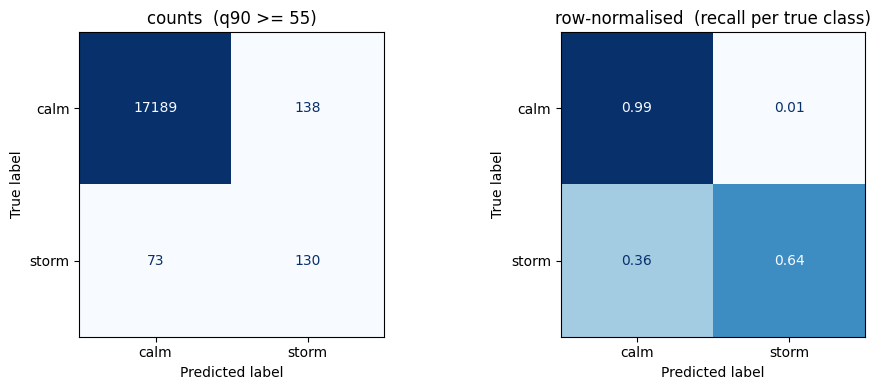

storms caught 130/203 (64%)  |  missed 73  |  false alarms 138  |  of all alarms, 49% were real storms


In [11]:
# Confusion matrices for the best warner: quantile with the validation-tuned q90 cutoff
y_hat = (q90 >= cut).astype(int)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(yc_test, y_hat),
                       display_labels=['calm', 'storm']).plot(ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title(f'counts  (q90 >= {cut})')
ConfusionMatrixDisplay(confusion_matrix(yc_test, y_hat, normalize='true'),
                       display_labels=['calm', 'storm']).plot(ax=ax[1], colorbar=False, cmap='Blues',
                                                              values_format='.2f')
ax[1].set_title('row-normalised  (recall per true class)')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(yc_test, y_hat).ravel()
print(f"storms caught {tp}/{tp+fn} ({tp/(tp+fn):.0%})  |  missed {fn}  |  false alarms {fp}  |  "
      f"of all alarms, {tp/(tp+fp):.0%} were real storms")

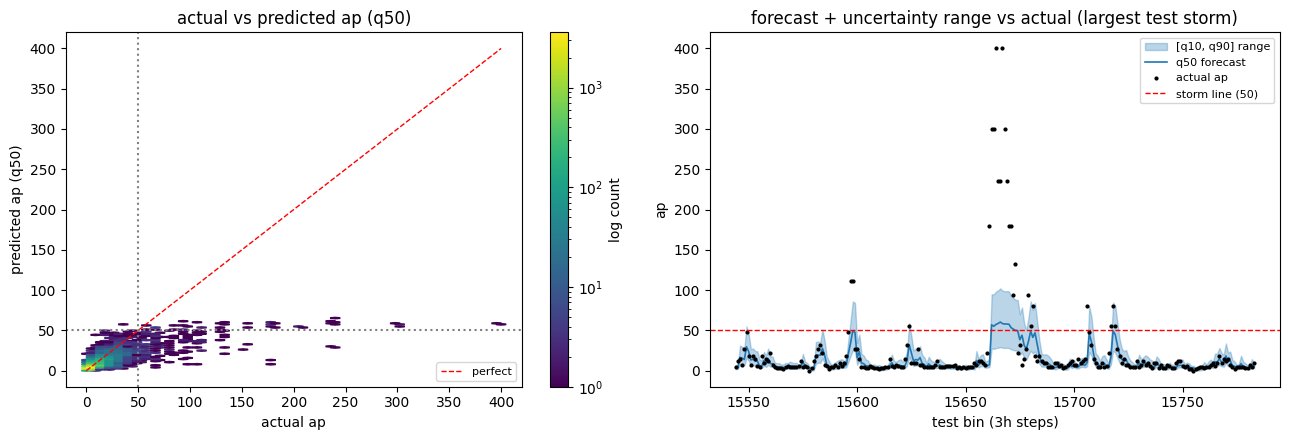

In [12]:
# Regression diagnostics for the quantile model
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) actual vs predicted point forecast (q50); log-density so the rare high-ap points show
yt = y_test.values
hb = ax[0].hexbin(yt, q50, gridsize=45, mincnt=1, bins='log', cmap='viridis')
lim = [0, max(yt.max(), q50.max())]
ax[0].plot(lim, lim, 'r--', lw=1, label='perfect')
ax[0].axhline(50, c='gray', ls=':'); ax[0].axvline(50, c='gray', ls=':')
ax[0].set(title='actual vs predicted ap (q50)', xlabel='actual ap', ylabel='predicted ap (q50)')
ax[0].legend(fontsize=8); fig.colorbar(hb, ax=ax[0], label='log count')

# (b) forecast + [q10, q90] range over the window around the biggest test storm
c = int(np.argmax(yt)); sl = slice(max(0, c - 120), c + 120)
t = np.arange(sl.start, sl.stop)
ax[1].fill_between(t, q10[sl], q90[sl], alpha=.30, color='tab:blue', label='[q10, q90] range')
ax[1].plot(t, q50[sl], color='tab:blue', lw=1.2, label='q50 forecast')
ax[1].plot(t, yt[sl], 'k.', ms=4, label='actual ap')
ax[1].axhline(50, c='r', ls='--', lw=1, label='storm line (50)')
ax[1].set(title='forecast + uncertainty range vs actual (largest test storm)',
          xlabel='test bin (3h steps)', ylabel='ap')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()